## 1. Load Dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 150)

df = pd.read_csv('/content/drive/MyDrive/ML/classification_data.csv')

## 2. Verify Dataset


In [ ]:
df.head(15)

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,2.068058,3.109704,3,-0.435250,1,4.635022,-0.683808,0.335669,0,1.286950,0
1,2.068058,0.684123,0,-0.435250,2,4.635022,0.625464,2.516940,0,2.031396,0
2,2.068058,1.765147,0,1.103605,5,3.736191,-1.011126,0.771923,0,1.783247,0
3,2.068058,2.265955,0,1.103605,0,2.837361,0.298146,0.117542,0,1.286950,0
4,2.068058,1.791405,0,-0.435250,2,2.837361,1.934737,0.662860,0,2.775843,0
5,2.068058,0.420484,0,-0.691726,0,2.837361,-0.029172,1.644432,0,1.286950,0
6,2.068058,0.420484,0,1.103605,5,2.837361,2.589373,1.535368,0,2.775843,0
7,2.068058,-0.106794,2,0.077702,5,2.837361,0.298146,2.844131,1,1.535098,0
8,2.068058,0.552303,0,-0.435250,2,2.837361,0.625464,1.426305,0,2.527694,0
9,2.068058,0.156740,2,3.668364,1,2.837361,2.589373,2.189750,0,2.031396,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58615 entries, 0 to 58614
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      58615 non-null  float64
 1   income                   58615 non-null  float64
 2   home_ownership           58615 non-null  int64  
 3   emplyment_length         58615 non-null  float64
 4   loan_intent              58615 non-null  int64  
 5   loan_amount              58615 non-null  float64
 6   loan_interest_rate       58615 non-null  float64
 7   loan_income_ratio        58615 non-null  float64
 8   payment_default_on_file  58615 non-null  int64  
 9   credit_history_length    58615 non-null  float64
 10  loan_approval_status     58615 non-null  int64  
dtypes: float64(7), int64(4)
memory usage: 4.9 MB


## 3. Input Features and Target


In [ ]:
feature_cols = ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent',
                'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
                'payment_default_on_file', 'credit_history_length']

X = df[feature_cols]
y = df['loan_approval_status']

In [ ]:
X.columns

Index(['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
       'payment_default_on_file', 'credit_history_length'],
      dtype='object')

In [ ]:
X.shape

(58615, 10)

In [ ]:
y.value_counts()

,count
loan_approval_status,
0,50270
1,8345


## 4. Train-Test Split


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
X_train.shape

(41030, 10)

In [ ]:
X_test.shape

(17585, 10)

In [ ]:
y_train.value_counts(normalize=True)

,proportion
loan_approval_status,
0,0.857641
1,0.142359


In [ ]:
y_test.value_counts(normalize=True)

,proportion
loan_approval_status,
0,0.857606
1,0.142394


## 5. Logistic Regression


In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=500)
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=500)

In [ ]:
y_pred_train_lr = logreg.predict(X_train)

In [ ]:
y_pred_lr = logreg.predict(X_test)

### 5.1 Logistic Regression — Evaluation


In [ ]:
Comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_lr})
Comparison_df

,Actual,Predicted
45327,0,0
15298,0,0
34262,0,0
46480,0,0
29640,0,0
...,...,...
55708,0,0
38334,0,0
26799,0,0
639,1,0


In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_train, y_pred_train_lr)
accuracy

0.8917621252741896

In [ ]:
accuracy = accuracy_score(y_test, y_pred_lr)
accuracy

0.8908729030423657

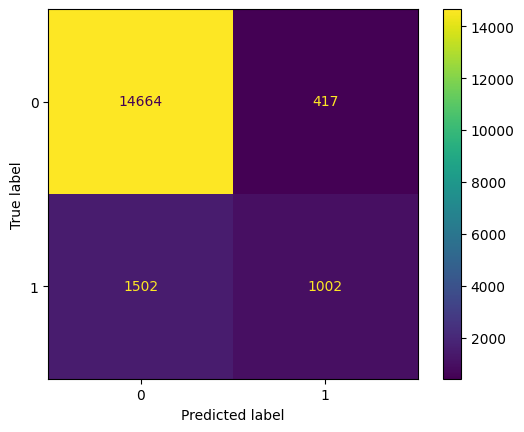

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr, labels=logreg.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=logreg.classes_)
disp.plot()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94     15081
           1       0.71      0.40      0.51      2504

    accuracy                           0.89     17585
   macro avg       0.81      0.69      0.72     17585
weighted avg       0.88      0.89      0.88     17585



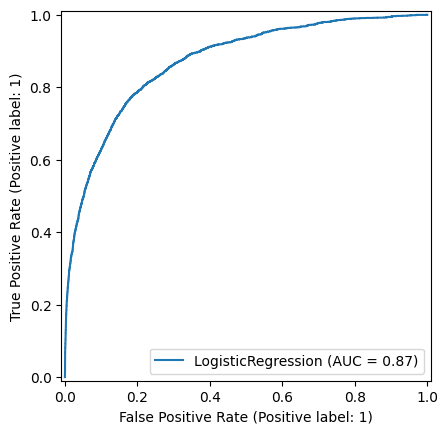

In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(logreg, X_test, y_test)

## 6. Naive Bayes


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred_train_nb = nb.predict(X_train)

In [ ]:
y_pred_nb = nb.predict(X_test)

### 6.1 Naive Bayes — Evaluation


In [ ]:
Comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_nb})
Comparison_df

,Actual,Predicted
45327,0,0
15298,0,0
34262,0,0
46480,0,0
29640,0,0
...,...,...
55708,0,0
38334,0,0
26799,0,0
639,1,1


In [ ]:
accuracy = accuracy_score(y_train, y_pred_train_nb)
accuracy

0.853204971971728

In [ ]:
accuracy = accuracy_score(y_test, y_pred_nb)
accuracy

0.8482797839067387

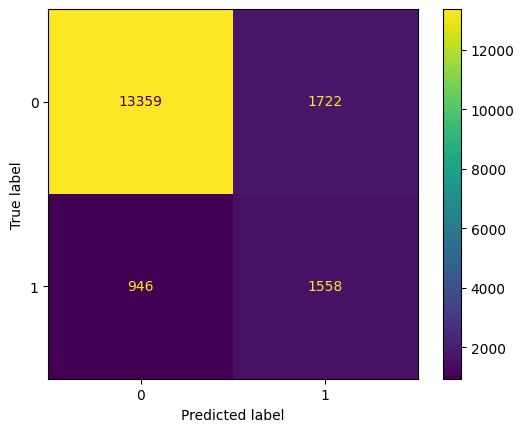

In [ ]:
cm = confusion_matrix(y_test, y_pred_nb, labels=nb.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=nb.classes_)
disp.plot()

In [ ]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.93      0.89      0.91     15081
           1       0.47      0.62      0.54      2504

    accuracy                           0.85     17585
   macro avg       0.70      0.75      0.72     17585
weighted avg       0.87      0.85      0.86     17585



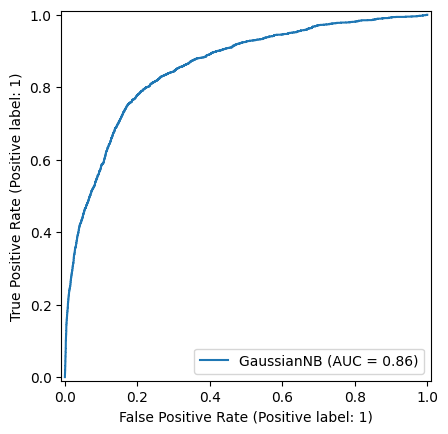

In [ ]:
RocCurveDisplay.from_estimator(nb, X_test, y_test)

## 7. K-Nearest Neighbours (K=5)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred_train_knn = knn.predict(X_train)

In [ ]:
y_pred_knn = knn.predict(X_test)

### 7.1 KNN — Evaluation


In [ ]:
Comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_knn})
Comparison_df

,Actual,Predicted
45327,0,0
15298,0,0
34262,0,0
46480,0,0
29640,0,0
...,...,...
55708,0,0
38334,0,0
26799,0,0
639,1,1


In [ ]:
accuracy = accuracy_score(y_train, y_pred_train_knn)
accuracy

0.9358518157445771

In [ ]:
accuracy = accuracy_score(y_test, y_pred_knn)
accuracy

0.916235427921524

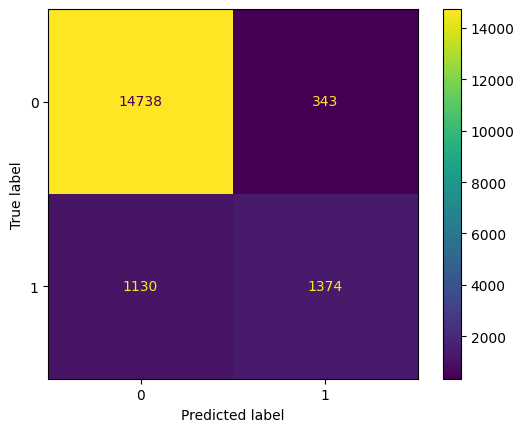

In [ ]:
cm = confusion_matrix(y_test, y_pred_knn, labels=knn.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=knn.classes_)
disp.plot()

In [ ]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95     15081
           1       0.80      0.55      0.65      2504

    accuracy                           0.92     17585
   macro avg       0.86      0.76      0.80     17585
weighted avg       0.91      0.92      0.91     17585



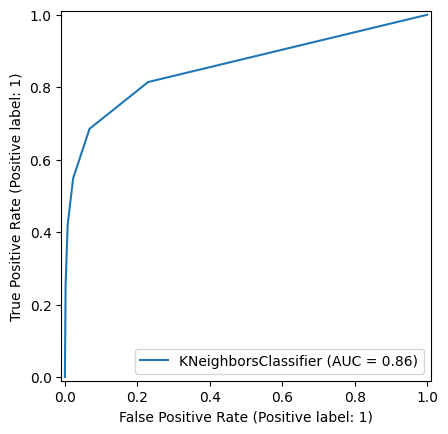

In [ ]:
RocCurveDisplay.from_estimator(knn, X_test, y_test)

## 8. Hyperparameter Tuning — Logistic Regression

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1, 10],
              'solver': ['lbfgs', 'liblinear'],
              'class_weight': [None, {0:1, 1:2}, 'balanced'],
              'max_iter': [500]}

logreg_gscv = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='f1')
logreg_gscv.fit(X_train, y_train)

logreg_gscv.best_params_

{'C': 0.1,
 'class_weight': {0: 1, 1: 2},
 'max_iter': 500,
 'solver': 'liblinear'}

In [ ]:
y_pred_lr_tuned = logreg_gscv.predict(X_test)

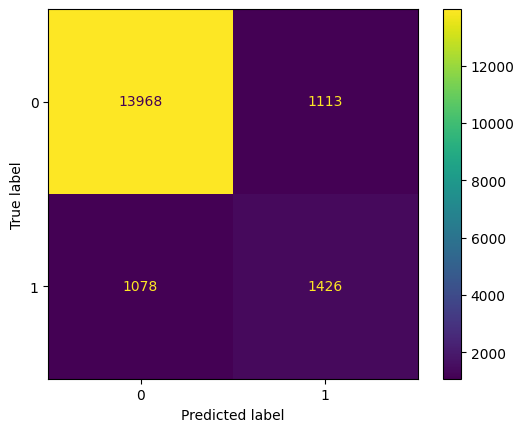

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr_tuned, labels=logreg_gscv.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=logreg_gscv.classes_)
disp.plot()

In [ ]:
print(classification_report(y_test, y_pred_lr_tuned))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93     15081
           1       0.56      0.57      0.57      2504

    accuracy                           0.88     17585
   macro avg       0.74      0.75      0.75     17585
weighted avg       0.88      0.88      0.88     17585



## 9. Hyperparameter Tuning — KNN


In [ ]:
param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 15],
              'weights': ['uniform', 'distance'],
              'metric': ['euclidean', 'manhattan']}

knn_gscv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1')
knn_gscv.fit(X_train, y_train)

knn_gscv.best_params_

{'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}

In [ ]:
y_pred_knn_tuned = knn_gscv.predict(X_test)

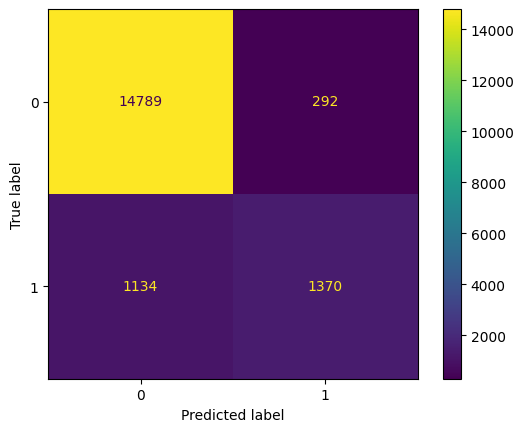

In [ ]:
cm = confusion_matrix(y_test, y_pred_knn_tuned, labels=knn_gscv.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=knn_gscv.classes_)
disp.plot()

In [ ]:
print(classification_report(y_test, y_pred_knn_tuned))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95     15081
           1       0.82      0.55      0.66      2504

    accuracy                           0.92     17585
   macro avg       0.88      0.76      0.81     17585
weighted avg       0.91      0.92      0.91     17585



## 10. Hyperparameter Tuning — Naive Bayes

In [ ]:
param_grid = {'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5],
              'priors': [None, [0.7, 0.3], [0.5, 0.5]]}

nb_gscv = GridSearchCV(GaussianNB(), param_grid, cv=5, scoring='f1')
nb_gscv.fit(X_train, y_train)

nb_gscv.best_params_

{'priors': None, 'var_smoothing': 1e-11}

In [ ]:
y_pred_nb_tuned = nb_gscv.predict(X_test)

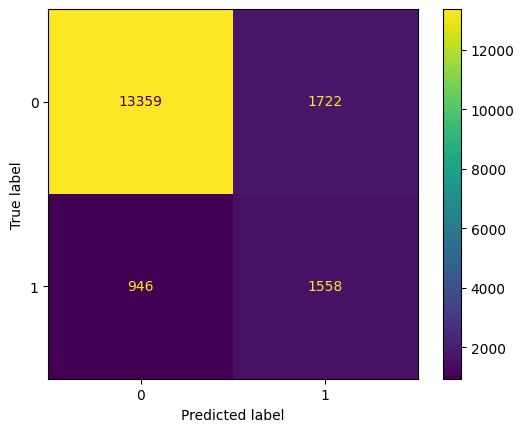

In [ ]:
cm = confusion_matrix(y_test, y_pred_nb_tuned, labels=nb_gscv.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=nb_gscv.classes_)
disp.plot()

In [ ]:
print(classification_report(y_test, y_pred_nb_tuned))

              precision    recall  f1-score   support

           0       0.93      0.89      0.91     15081
           1       0.47      0.62      0.54      2504

    accuracy                           0.85     17585
   macro avg       0.70      0.75      0.72     17585
weighted avg       0.87      0.85      0.86     17585

